In [1]:
LOG_DIR = '../../experiments/current/'


In [2]:
# Parameters
LOG_DIR = "../../experiments/current/"


In [3]:
import pandas as pd
import json
import os


def load_jsonl(path):
    """Charge un fichier de JSON objets concaténés (format multi-lignes ou NDJSON)."""
    with open(path) as f:
        content = f.read()
    if not content.strip():
        return pd.DataFrame()
    decoder = json.JSONDecoder()
    records, pos = [], 0
    while pos < len(content):
        try:
            obj, end = decoder.raw_decode(content, pos)
            records.append(obj)
            pos = end
            while pos < len(content) and content[pos] in ' \n\t\r':
                pos += 1
        except json.JSONDecodeError:
            break
    df = pd.DataFrame(records)
    if not df.empty and 'time' in df.columns:
        df['time'] = pd.to_datetime(df['time'])
    return df

# overwrite with actual folder

df_success = load_jsonl(LOG_DIR + 'llm_exchanges.jsonl')
df_error   = load_jsonl(LOG_DIR + 'llm_errors.jsonl')
#df_success = load_jsonl('../../experiments/2026-05-15_12_26/llm_exchanges.jsonl')
#df_error   = load_jsonl('../../experiments/2026-05-15_12_26/llm_errors.jsonl')

print(f"Succès : {len(df_success)} | Erreurs : {len(df_error)}")
df_success.head()

def _img_path(title, ext="png"):
    name = "".join(c if c.isalnum() or c in "-_" else "_" for c in title)
    img_dir = os.path.join(LOG_DIR, "images/llm_traffic")
    os.makedirs(img_dir, exist_ok=True)
    return os.path.join(img_dir, f"{name}.{ext}")


Succès : 1211 | Erreurs : 1008


In [4]:
df_success.columns

df_freq = df_success[['time', 'provider']]

df_freq

,time,provider
0,2026-06-10 16:57:46.825524+00:00,groq_llama31
1,2026-06-10 16:57:47.294531+00:00,groq_llama4
2,2026-06-10 16:57:49.208692+00:00,groq_qwen
3,2026-06-10 16:57:51.537165+00:00,mistral
4,2026-06-10 16:57:56.094135+00:00,mistral
...,...,...
1206,2026-06-10 18:48:43.185771+00:00,groq_llama3
1207,2026-06-10 18:48:43.477481+00:00,mistral
1208,2026-06-10 18:48:49.161212+00:00,mistral
1209,2026-06-10 18:48:51.349367+00:00,mistral


## Appels par minute par provider (succès / erreurs)

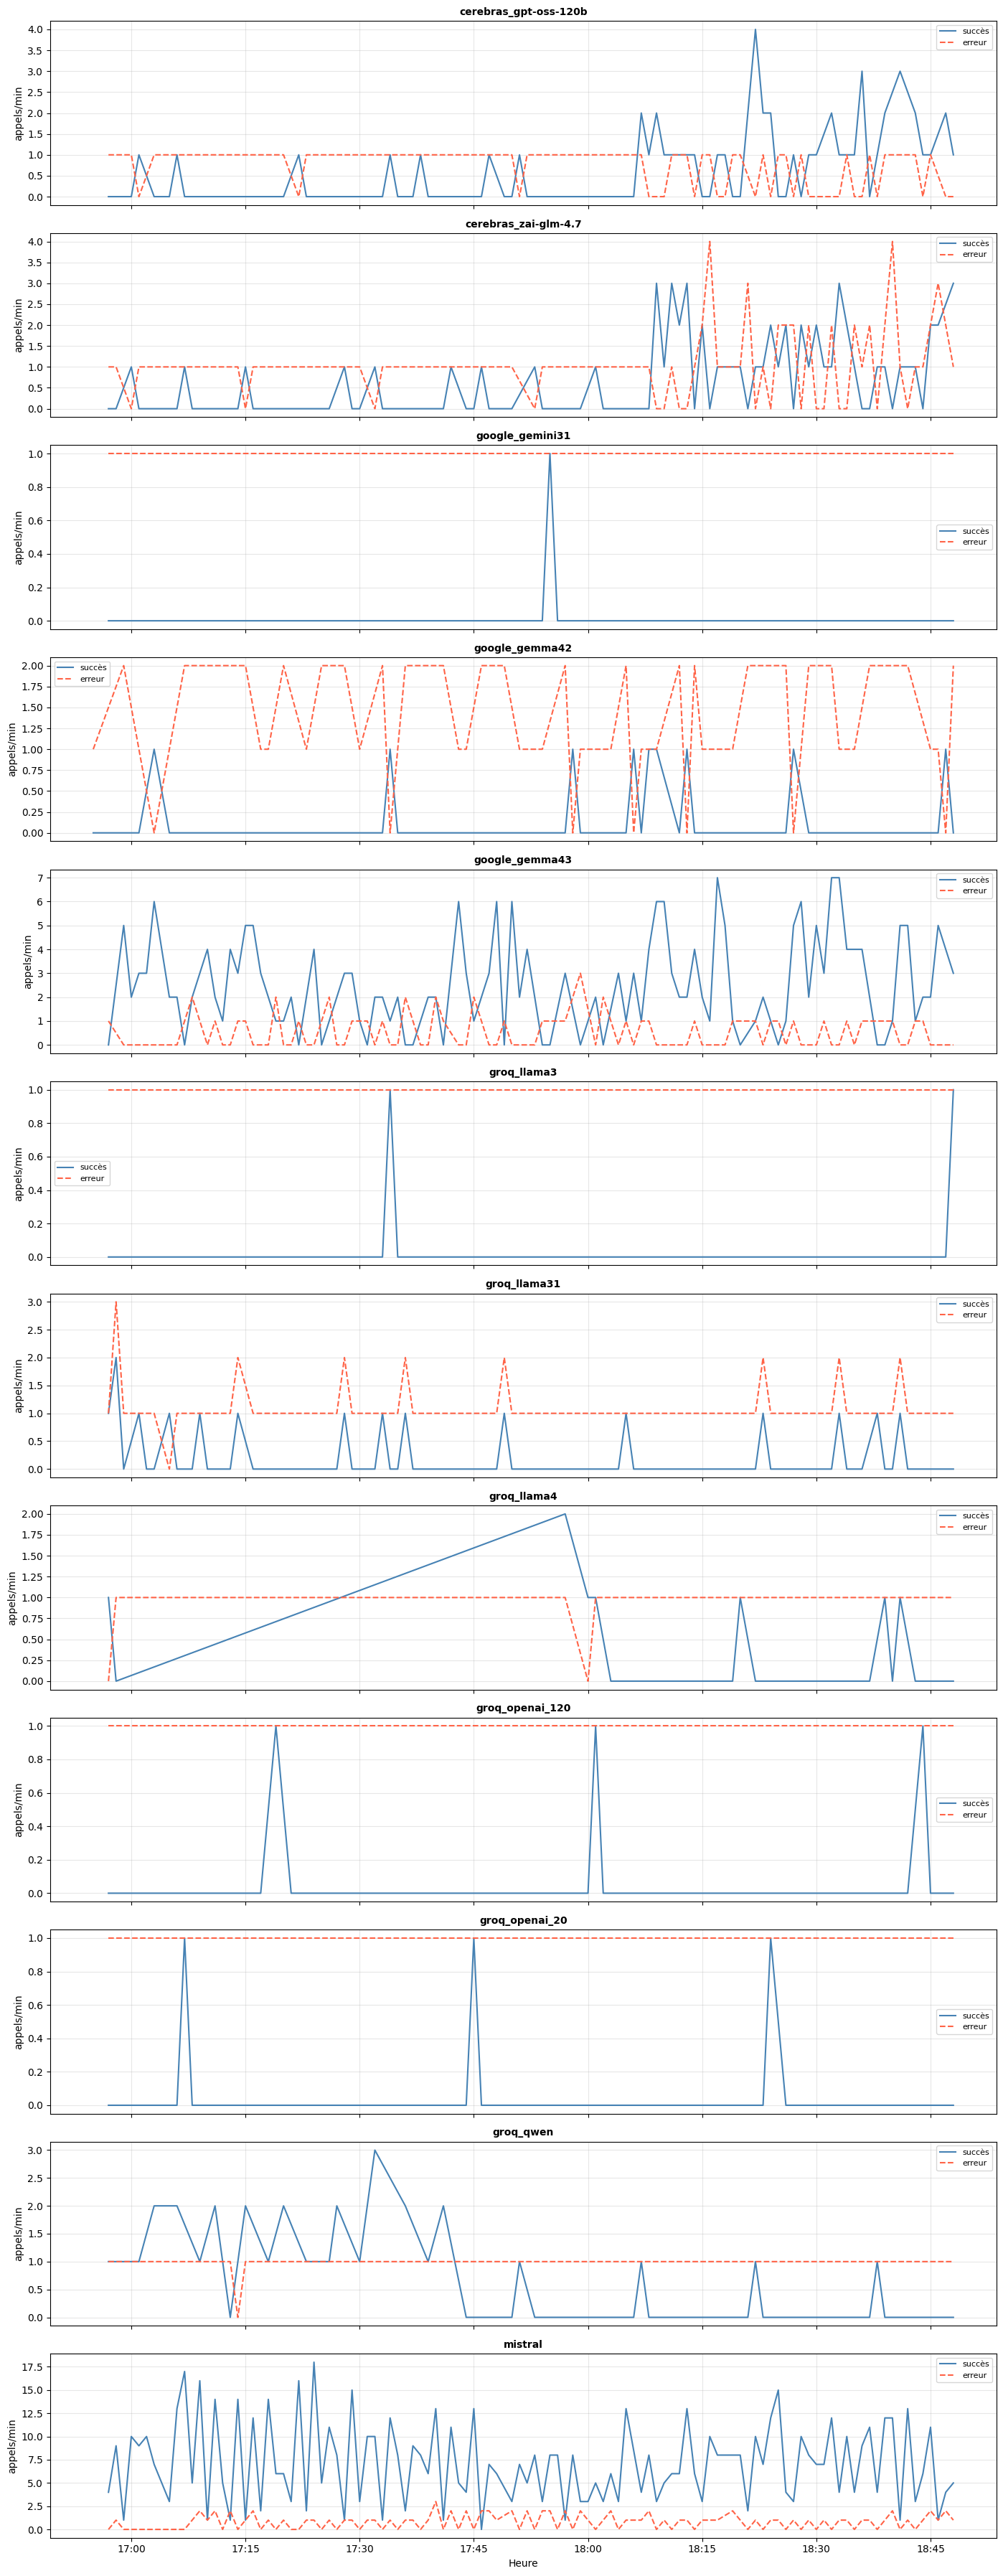

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Combiner succès et erreurs avec statut
df_s = df_success[['time', 'provider']].copy()
df_s['status'] = 'success'

df_e = df_error[['time', 'provider']].copy()
df_e['status'] = 'error'

df_all = pd.concat([df_s, df_e], ignore_index=True)
df_all['minute'] = df_all['time'].dt.floor('min')

# Compter les appels par minute, provider et statut
calls_per_min = (
    df_all.groupby(['minute', 'provider', 'status'])
    .size()
    .unstack('status', fill_value=0)
)

providers_sorted = sorted(df_all['provider'].unique())
n = len(providers_sorted)

fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, prov in zip(axes, providers_sorted):
    if prov in calls_per_min.index.get_level_values('provider'):
        prov_data = calls_per_min.xs(prov, level='provider')
        if 'success' in prov_data.columns:
            ax.plot(prov_data.index, prov_data['success'], label='succès', color='steelblue', linewidth=1.5)
        if 'error' in prov_data.columns:
            ax.plot(prov_data.index, prov_data['error'], label='erreur', color='tomato', linestyle='--', linewidth=1.5)
    ax.set_title(prov, fontsize=10, fontweight='bold')
    ax.set_ylabel('appels/min')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.grid(True, alpha=0.3)

plt.savefig(_img_path("provider_calls"), dpi=200)

plt.xlabel('Heure')
plt.tight_layout()
plt.show()


## Taux de réussite par provider

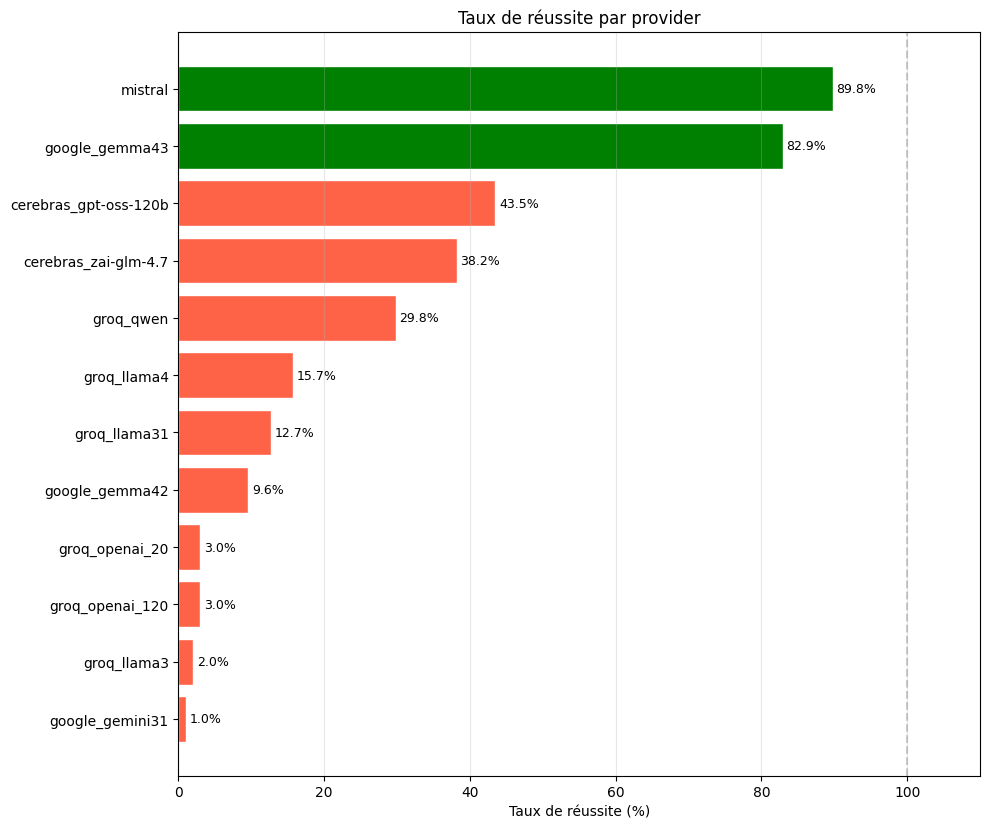

,total,success,errors,max_appels/min,taux_réussite
provider,,,,,
mistral,857,770,87,19,89.8
google_gemma43,310,257,53,7,82.9
cerebras_gpt-oss-120b,115,50,65,4,43.5
cerebras_zai-glm-4.7,152,58,94,5,38.2
groq_qwen,114,34,80,4,29.8
groq_llama4,51,8,43,3,15.7
groq_llama31,126,16,110,5,12.7
google_gemma42,94,9,85,2,9.6
groq_openai_120,101,3,98,2,3.0


In [6]:
total_calls = df_all.groupby('provider').size().rename('total')
success_counts = df_all[df_all['status'] == 'success'].groupby('provider').size().rename('success')
error_counts = df_all[df_all['status'] == 'error'].groupby('provider').size().rename('errors')

# Max d'appels sur une minute (toutes minutes confondues, success + erreurs)
calls_per_min_total = (
    df_all.groupby(['provider', 'minute'])
    .size()
)
max_calls_per_min = calls_per_min_total.groupby('provider').max().rename('max_appels/min')

summary = pd.concat([total_calls, success_counts, error_counts, max_calls_per_min], axis=1).fillna(0)
summary[['total', 'success', 'errors', 'max_appels/min']] = summary[['total', 'success', 'errors', 'max_appels/min']].astype(int)
summary['taux_réussite'] = (summary['success'] / summary['total'] * 100).round(1)
summary = summary.sort_values('taux_réussite')

# Graphique
fig, ax = plt.subplots(figsize=(10, max(4, len(summary) * 0.7)))

colors = ['green' if v >= 80 else 'orange' if v >= 50 else 'tomato' for v in summary['taux_réussite']]
bars = ax.barh(summary.index, summary['taux_réussite'], color=colors, edgecolor='white')

for bar, val in zip(bars, summary['taux_réussite']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Taux de réussite (%)')
ax.set_title('Taux de réussite par provider')
ax.set_xlim(0, 110)
ax.axvline(x=100, color='gray', linestyle='--', alpha=0.4)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(_img_path("provider_success_rate"), dpi=200)
plt.show()

# Tableau récapitulatif
summary.sort_values('taux_réussite', ascending=False)


## Principales erreurs par provider

In [7]:
summary_errors = pd.DataFrame(
    df_error.groupby(['provider', 'error_type', 'error_message'])
    .size()
    .sort_values(ascending=False)
    .reset_index(name='count')
)

summary_errors = summary_errors[summary_errors['count'] > 1]

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
display(summary_errors.head(20))


,provider,error_type,error_message,count
0,mistral,rate limit exceeded,"[mistral] HTTP 429: {""object"":""error"",""message"":""Rate limit exceeded"",""type"":""rate_limited"",""param"":null,""code"":""1300"",""raw_status_code"":429}",63
1,google_gemma42,max_tokens_truncation,[google_gemma42] HTTP 503: Output truncated at MAX_TOKENS limit (possible repetition loop),62
2,cerebras_zai-glm-4.7,tokens per day limit exceeded - too many tokens processed.,"[cerebras_zai-glm-4.7] HTTP 429: {""message"":""Tokens per day limit exceeded - too many tokens processed."",""type"":""too_many_tokens_error"",""param"":""quota"",""code"":""token_quota_exceeded""}",46
3,cerebras_gpt-oss-120b,tokens per day limit exceeded - too many tokens processed.,"[cerebras_gpt-oss-120b] HTTP 429: {""message"":""Tokens per day limit exceeded - too many tokens processed."",""type"":""too_many_tokens_error"",""param"":""quota"",""code"":""token_quota_exceeded""}",41
4,google_gemma43,max_tokens_truncation,[google_gemma43] HTTP 503: Output truncated at MAX_TOKENS limit (possible repetition loop),33
5,cerebras_zai-glm-4.7,parse error jsondecodeerror: expecting value: line 1 column 1 (char,[cerebras_zai-glm-4.7] Parse error: JSONDecodeError: Expecting value: line 1 column 1 (char 0),30
6,cerebras_gpt-oss-120b,we're experiencing high traffic right now! please try again soon.,"[cerebras_gpt-oss-120b] HTTP 429: {""message"":""We're experiencing high traffic right now! Please try again soon."",""type"":""too_many_requests_error"",""param"":""queue"",""code"":""queue_exceeded""}",23
7,google_gemma42,unknown,[google] HTTP 400: Réponse bloquée ou vide. Raison: RECITATION,14
8,google_gemma43,unknown,[google] HTTP 400: Réponse bloquée ou vide. Raison: RECITATION,10
9,google_gemma43,timeout,[google] HTTP 504: Request timeout: The read operation timed out,4


## Tokens par catégorie de prompt

Session complète — tokens_in=4,774,377  tokens_out=1,003,383  total=5,777,760



,appels,agents_total,in_min,in_mean,in_max,out_min,out_mean,out_max,total_tokens_in,total_tokens_out,total_tokens_total
category,,,,,,,,,,,
itinary_multi_agent,773,2589,360,1229,3228,50,269,3217,2617276,474259,3091535
ltm_self_reflection,101,189,927,2549,6816,141,336,2211,474670,58940,533610
stm_reflection,337,1152,911,1555,4547,131,535,3295,1682431,470184,2152615



=== Vérification cohérence avec llm_config.py ===
  ⚠️  [itinary_multi_agent] tokens_in/agent max=3228 dépasse assumed_prompt_tokens=2200
  ℹ️  [itinary_multi_agent] tokens_out/agent mean=269 < min_output_tokens=512 (réponses courtes)
  ⚠️  [ltm_self_reflection] tokens_in/agent max=6816 dépasse assumed_prompt_tokens=2200
  ℹ️  [ltm_self_reflection] tokens_out/agent mean=336 < min_output_tokens=512 (réponses courtes)
  ⚠️  [stm_reflection] tokens_in/agent max=4547 dépasse assumed_prompt_tokens=2200


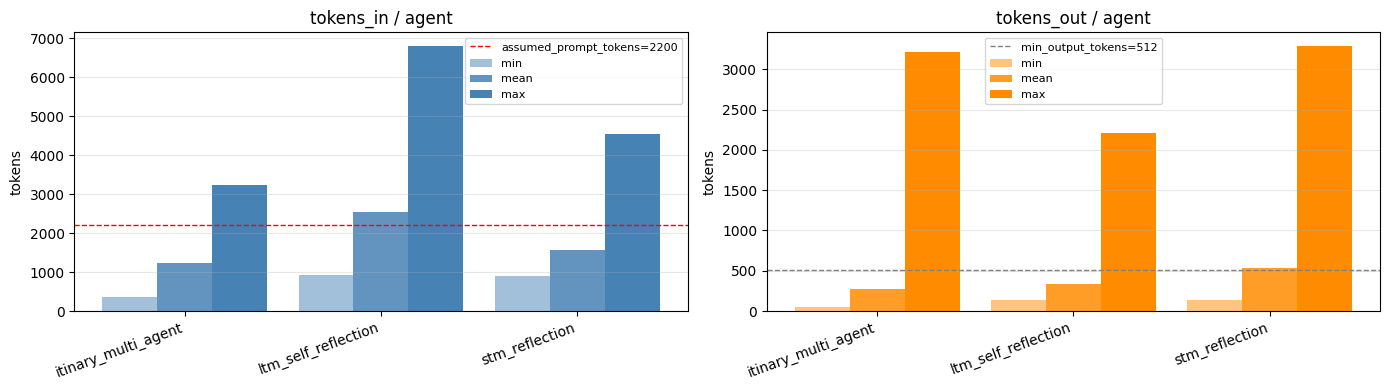

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ── Vérification présence colonne category ──────────────────────────────────
if "category" not in df_success.columns or df_success["category"].eq("").all():
    print("⚠️  Colonne 'category' absente ou vide — les échanges loggés avant cet ajout ne contiennent pas la catégorie.")
    print("   Relancez une simulation pour obtenir des données annotées.")
else:
    df_tok = df_success.copy()
    df_tok["tokens_total"] = df_tok["tokens_in"] + df_tok["tokens_out"]
    df_tok["agents_count"] = df_tok["response"].apply(lambda r: max(len(r), 1) if isinstance(r, list) else 1)
    df_tok["tokens_in_per_agent"]  = df_tok["tokens_in"]    / df_tok["agents_count"]
    df_tok["tokens_out_per_agent"] = df_tok["tokens_out"]   / df_tok["agents_count"]

    # ── Stats par catégorie ───────────────────────────────────────────────────
    agg = df_tok.groupby("category").agg(
        appels         =("tokens_in",           "count"),
        agents_total   =("agents_count",         "sum"),
        in_min         =("tokens_in_per_agent",  "min"),
        in_mean        =("tokens_in_per_agent",  "mean"),
        in_max         =("tokens_in_per_agent",  "max"),
        out_min        =("tokens_out_per_agent", "min"),
        out_mean       =("tokens_out_per_agent", "mean"),
        out_max        =("tokens_out_per_agent", "max"),
        total_tokens_in =("tokens_in",  "sum"),
        total_tokens_out=("tokens_out", "sum"),
    ).round(0)

    # inf (division par 0) puis NaN → 0
    bad_cols = agg.columns[agg.isin([np.inf, -np.inf]).any() | agg.isna().any()].tolist()
    if bad_cols:
        print(f"⚠️  Valeurs non-finies (inf/NaN) détectées dans : {bad_cols} — remplacées par 0.")

    agg = (agg
           .replace([np.inf, -np.inf], np.nan)
           .fillna(0)
           .astype({c: int for c in ["appels","agents_total","in_min","in_mean","in_max","out_min","out_mean","out_max","total_tokens_in","total_tokens_out"]}))

    agg["total_tokens_total"] = agg["total_tokens_in"] + agg["total_tokens_out"]

    # ── Totaux session ────────────────────────────────────────────────────────
    session_in    = int(df_tok["tokens_in"].sum())
    session_out   = int(df_tok["tokens_out"].sum())
    session_total = session_in + session_out

    print(f"Session complète — tokens_in={session_in:,}  tokens_out={session_out:,}  total={session_total:,}")
    print()

    # Tableau stats par catégorie
    display(agg[["appels","agents_total",
                 "in_min","in_mean","in_max",
                 "out_min","out_mean","out_max",
                 "total_tokens_in","total_tokens_out","total_tokens_total"]])

    # ── Vérification cohérence avec llm_config.py ────────────────────────────
    ASSUMED_PROMPT_TOKENS = 2200   # Settings.assumed_prompt_tokens
    MIN_OUTPUT_TOKENS     = 512    # Settings.min_output_tokens

    print()
    print("=== Vérification cohérence avec llm_config.py ===")
    any_warning = False
    for cat, row in agg.iterrows():
        flag_in  = row["in_max"]  > ASSUMED_PROMPT_TOKENS
        flag_out = row["out_min"] < MIN_OUTPUT_TOKENS and row["out_mean"] < MIN_OUTPUT_TOKENS
        if flag_in:
            print(f"  ⚠️  [{cat}] tokens_in/agent max={row['in_max']} dépasse assumed_prompt_tokens={ASSUMED_PROMPT_TOKENS}")
            any_warning = True
        if flag_out:
            print(f"  ℹ️  [{cat}] tokens_out/agent mean={row['out_mean']} < min_output_tokens={MIN_OUTPUT_TOKENS} (réponses courtes)")
    if not any_warning:
        print(f"  ✅ tokens_in/agent max ≤ assumed_prompt_tokens={ASSUMED_PROMPT_TOKENS} sur toutes les catégories")

    # ── Graphique min/mean/max tokens_in par catégorie ────────────────────────
    cats = list(agg.index)
    x    = np.arange(len(cats))
    w    = 0.28

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(cats) * 0.9)))

    for ax, col_prefix, label, color in [
        (axes[0], "in",  "tokens_in / agent",  "steelblue"),
        (axes[1], "out", "tokens_out / agent", "darkorange"),
    ]:
        mins   = agg[f"{col_prefix}_min"].values
        means  = agg[f"{col_prefix}_mean"].values
        maxs   = agg[f"{col_prefix}_max"].values

        ax.bar(x - w, mins,  w, label="min",  color=color, alpha=0.5)
        ax.bar(x,     means, w, label="mean", color=color, alpha=0.85)
        ax.bar(x + w, maxs,  w, label="max",  color=color, alpha=1.0)

        if col_prefix == "in":
            ax.axhline(ASSUMED_PROMPT_TOKENS, color="red", linestyle="--", linewidth=1, label=f"assumed_prompt_tokens={ASSUMED_PROMPT_TOKENS}")
        else:
            ax.axhline(MIN_OUTPUT_TOKENS, color="gray", linestyle="--", linewidth=1, label=f"min_output_tokens={MIN_OUTPUT_TOKENS}")

        ax.set_xticks(x)
        ax.set_xticklabels(cats, rotation=20, ha="right")
        ax.set_title(label)
        ax.set_ylabel("tokens")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(_img_path("tokens_par_categorie"), dpi=200)
    plt.show()
